In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 

In [48]:
df_orgin = pd.read_csv('Dataset/CC GENERAL.csv')
df=df_orgin.copy()
df_stan=df_orgin.copy()


In [49]:
df=df.drop('CUST_ID',axis=1)
df_stan=df_stan.drop('CUST_ID',axis=1)

df.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='str')

BALANCE: Balance amount left in customer's account to make purchases.

BALANCE_FREQUENCY: How frequently the Balance is updated (score between 0 and 1).

PURCHASES: Total amount of purchases made from the account.

ONEOFF_PURCHASES: Maximum purchase amount done in a single transaction.

INSTALLMENTS_PURCHASES: Amount of purchases done in installments.

CASH_ADVANCE: Cash in advance given by the user.

PURCHASES_FREQUENCY: How frequently purchases are being made (score between 0 and 1).

ONEOFF_PURCHASES_FREQUENCY: How frequently one-go purchases occur (score between 0 and 1).

PURCHASES_INSTALLMENTS_FREQUENCY: How frequently installment purchases are being done.

CASH_ADVANCE_FREQUENCY: How frequently the cash in advance is being paid.

CASH_ADVANCE_TRX: Number of transactions made with "Cash in Advance."

PURCHASES_TRX: Number of purchase transactions made.

CREDIT_LIMIT: Limit of credit card for the user.

PAYMENTS: Total amount of payments done by the user.

MINIMUM_PAYMENTS: Minimum amount of payments made by the user.

PRC_FULL_PAYMENT: Percentage of full payment paid by the user.

TENURE: Tenure of credit card service for the user.

In [4]:
df.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [55]:
df['MINIMUM_PAYMENTS'].median()

np.float64(312.343947)

In [5]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

In [6]:
mask = (df['PAYMENTS'] ==0)
df.loc[mask,'MINIMUM_PAYMENTS'] =0 

In [7]:
df.isnull().sum()

BALANCE                              0
BALANCE_FREQUENCY                    0
PURCHASES                            0
ONEOFF_PURCHASES                     0
INSTALLMENTS_PURCHASES               0
CASH_ADVANCE                         0
PURCHASES_FREQUENCY                  0
ONEOFF_PURCHASES_FREQUENCY           0
PURCHASES_INSTALLMENTS_FREQUENCY     0
CASH_ADVANCE_FREQUENCY               0
CASH_ADVANCE_TRX                     0
PURCHASES_TRX                        0
CREDIT_LIMIT                         0
PAYMENTS                             0
MINIMUM_PAYMENTS                    73
PRC_FULL_PAYMENT                     0
TENURE                               0
dtype: int64

In [8]:
df['MINIMUM_PAYMENTS']=df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

In [9]:
df.isna().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [10]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.282473,1733.143852,836.386112,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.646702,2895.063757,2335.282201,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,164.653643,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,294.572557,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,788.713501,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


array([[<Axes: title={'center': 'BALANCE'}>,
        <Axes: title={'center': 'BALANCE_FREQUENCY'}>,
        <Axes: title={'center': 'PURCHASES'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES'}>],
       [<Axes: title={'center': 'INSTALLMENTS_PURCHASES'}>,
        <Axes: title={'center': 'CASH_ADVANCE'}>,
        <Axes: title={'center': 'PURCHASES_FREQUENCY'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES_FREQUENCY'}>],
       [<Axes: title={'center': 'PURCHASES_INSTALLMENTS_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_TRX'}>,
        <Axes: title={'center': 'PURCHASES_TRX'}>],
       [<Axes: title={'center': 'CREDIT_LIMIT'}>,
        <Axes: title={'center': 'PAYMENTS'}>,
        <Axes: title={'center': 'MINIMUM_PAYMENTS'}>,
        <Axes: title={'center': 'PRC_FULL_PAYMENT'}>],
       [<Axes: title={'center': 'TENURE'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

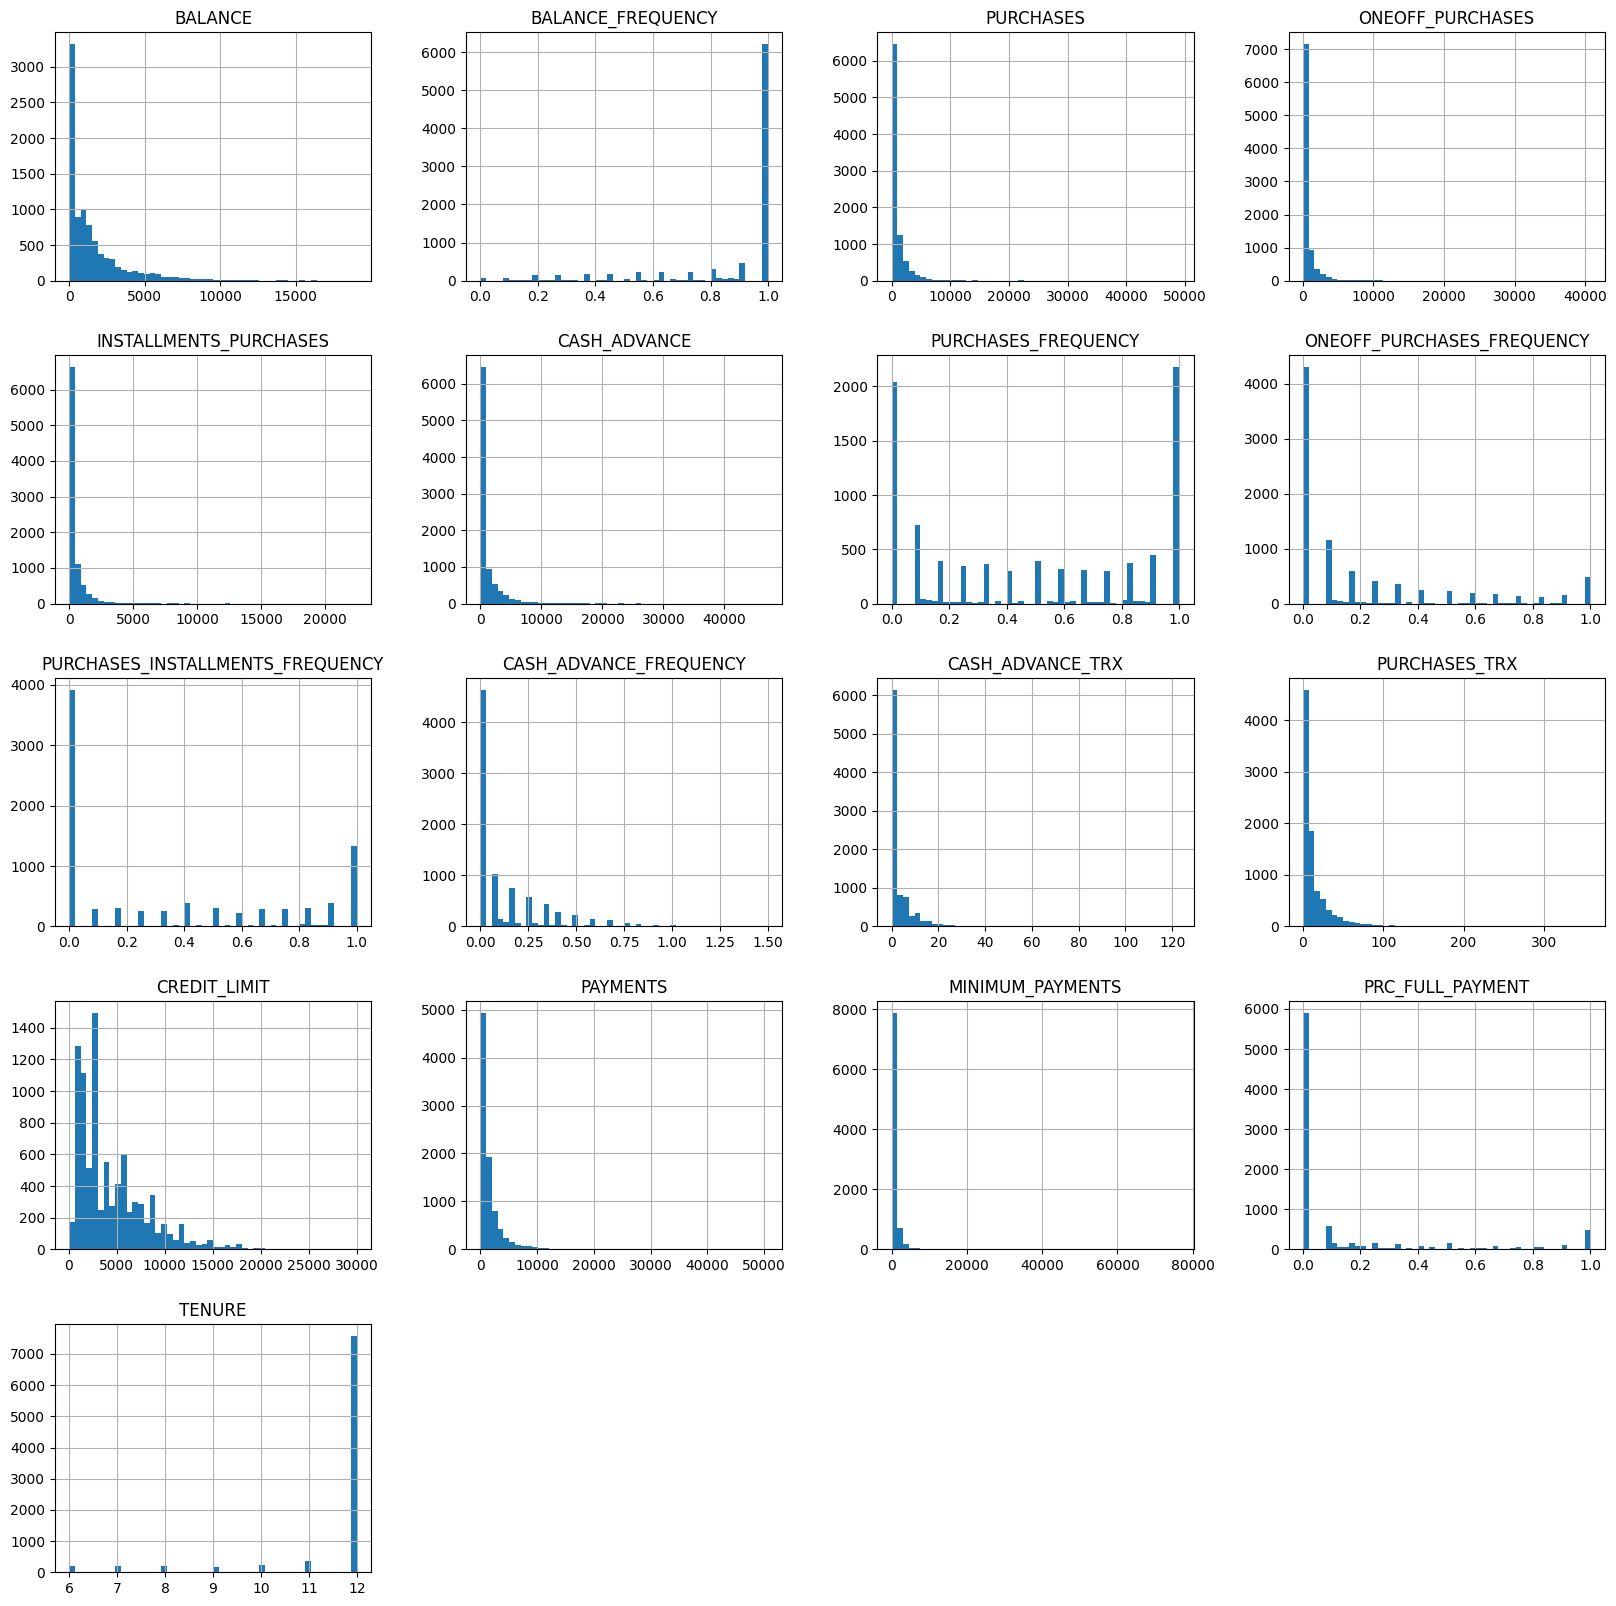

In [11]:
df.hist(bins=50,figsize=(20,20))

In [12]:
df.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='str')

In [13]:
df = np.log2(df+0.01)

In [14]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,5.354408,-0.271980,6.576069,-6.643856,6.576069,-6.643856,-2.500896,-6.643856,-3.421469,-6.643856,-6.643856,1.007196,9.965799,7.656869,7.124326,-6.643856,3.586164
1,11.644973,-0.121720,-6.643856,-6.643856,-6.643856,12.653507,-6.643856,-6.643856,-6.643856,-1.943416,2.003602,-6.643856,12.773141,12.002478,10.066560,-2.106423,3.586164
2,11.284916,0.014355,9.594661,9.594661,-6.643856,-6.643856,0.014355,0.014355,-6.643856,-6.643856,-6.643856,3.586164,12.872677,9.280949,9.293000,-6.643856,3.586164
3,10.702762,-0.629581,10.549794,10.549794,-6.643856,7.685085,-3.421469,-3.421469,-6.643856,-3.421469,0.014355,0.014355,12.872677,-6.643856,-6.643856,-6.643856,3.586164
4,9.675471,0.014355,4.000901,4.000901,-6.643856,-6.643856,-3.421469,-3.421469,-6.643856,-6.643856,-6.643856,0.014355,10.228831,9.405875,7.935467,-6.643856,3.586164


array([[<Axes: title={'center': 'BALANCE'}>,
        <Axes: title={'center': 'BALANCE_FREQUENCY'}>,
        <Axes: title={'center': 'PURCHASES'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES'}>],
       [<Axes: title={'center': 'INSTALLMENTS_PURCHASES'}>,
        <Axes: title={'center': 'CASH_ADVANCE'}>,
        <Axes: title={'center': 'PURCHASES_FREQUENCY'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES_FREQUENCY'}>],
       [<Axes: title={'center': 'PURCHASES_INSTALLMENTS_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_TRX'}>,
        <Axes: title={'center': 'PURCHASES_TRX'}>],
       [<Axes: title={'center': 'CREDIT_LIMIT'}>,
        <Axes: title={'center': 'PAYMENTS'}>,
        <Axes: title={'center': 'MINIMUM_PAYMENTS'}>,
        <Axes: title={'center': 'PRC_FULL_PAYMENT'}>],
       [<Axes: title={'center': 'TENURE'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

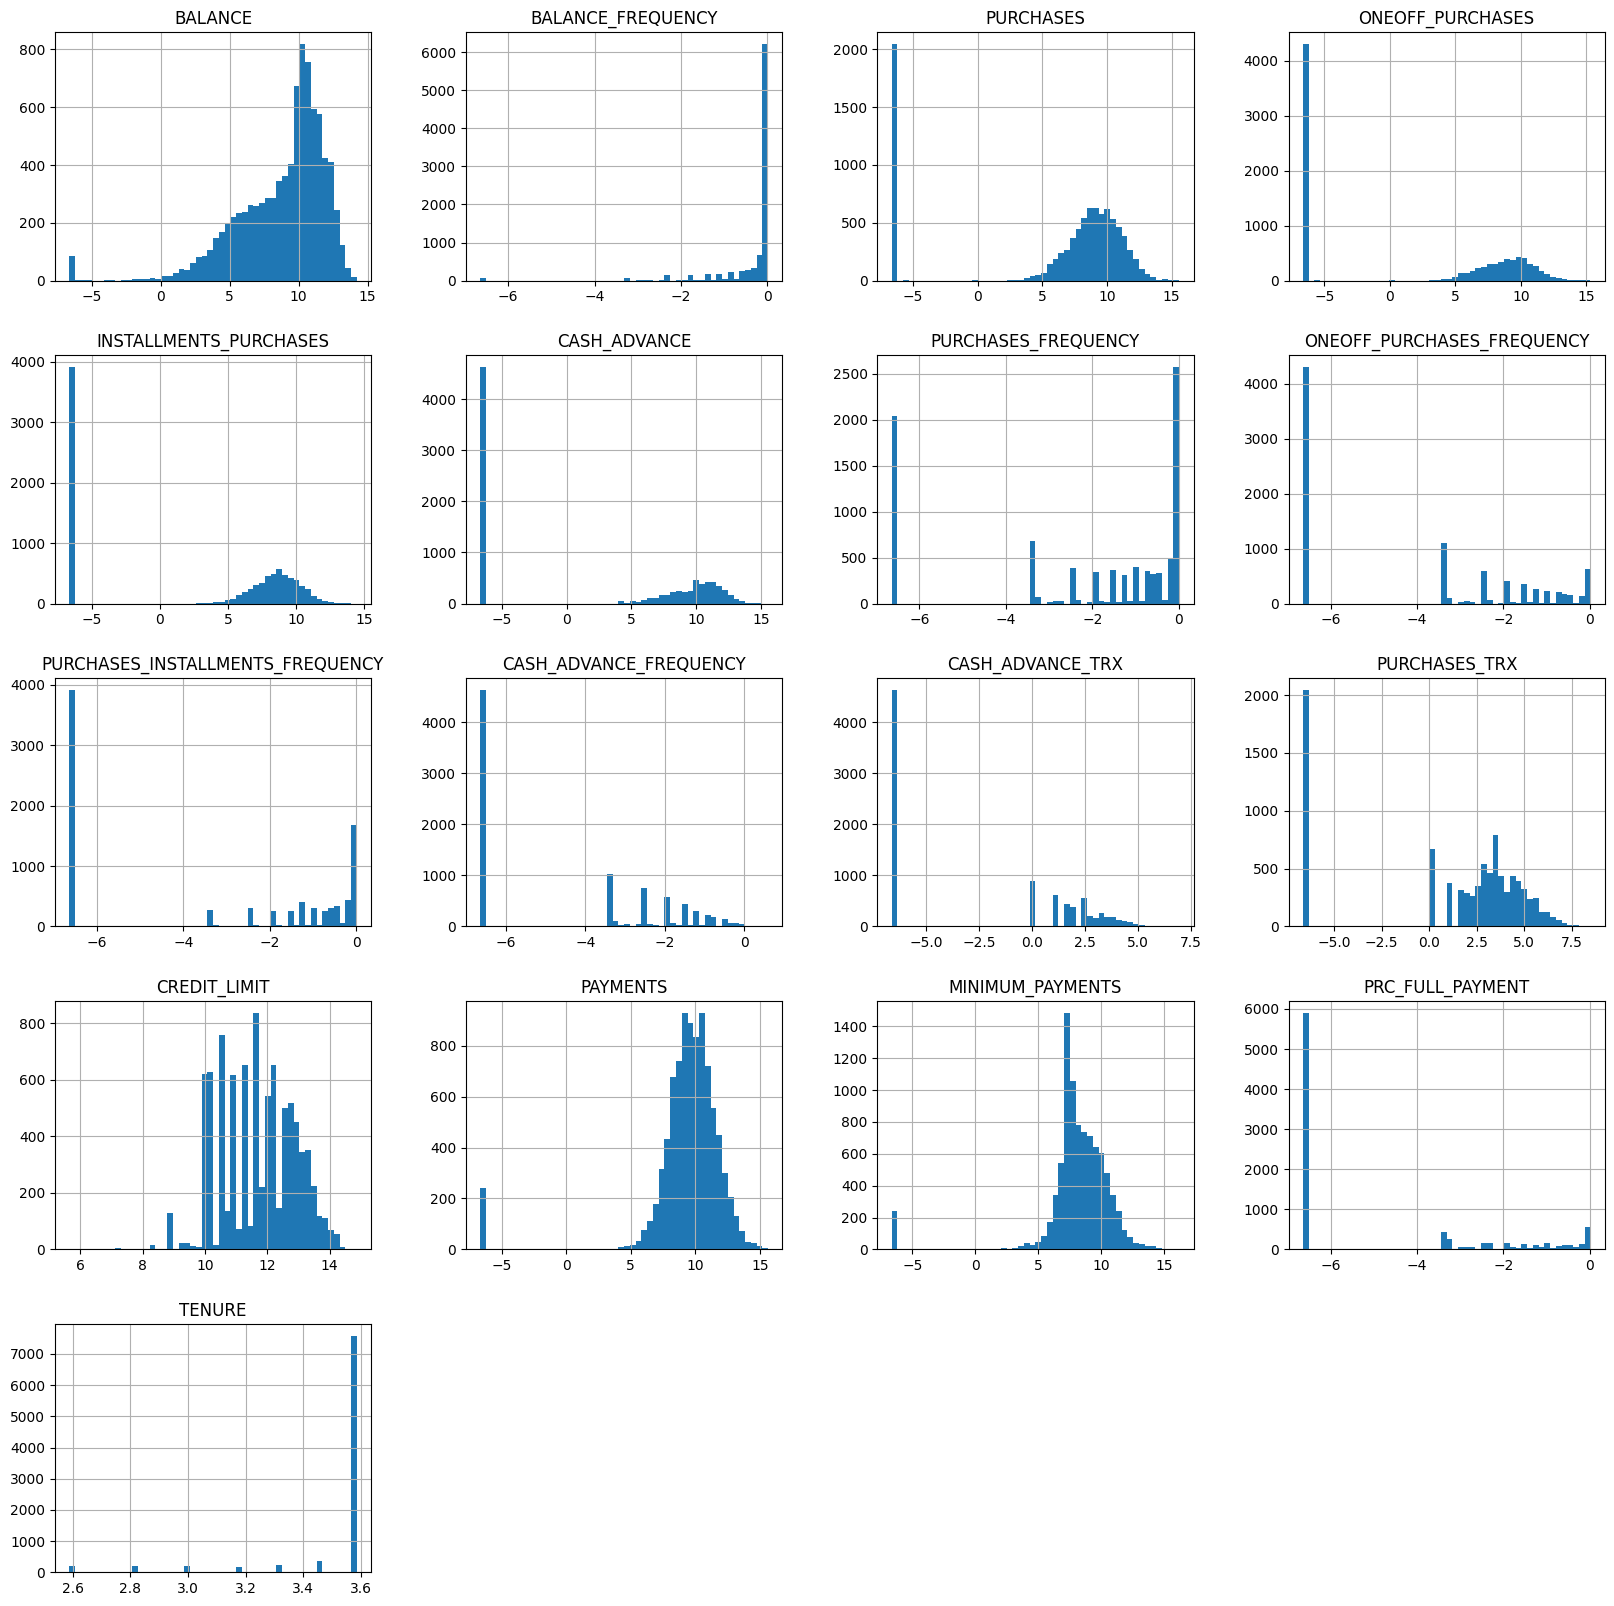

In [15]:
df.hist(bins=50,figsize=(20,20))

In [16]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist
from sklearn.metrics import silhouette_score


In [17]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)


In [18]:
pca = PCA(n_components=12)
pca_components = pca.fit_transform(df_scaled)

In [31]:
gm = GaussianMixture(n_components=7, random_state=42).fit(pca_components)

labels = gm.predict(pca_components)

In [34]:
labels_cnt=pd.DataFrame(labels)
labels_cnt.value_counts()

0
3    2039
1    1797
4    1761
6    1069
5    1019
0     804
2     461
Name: count, dtype: int64

In [21]:

X_Unscaled = TSNE(n_components=2, learning_rate='auto',
                  init='pca', perplexity=30,n_jobs=-1).fit_transform(pca_components)


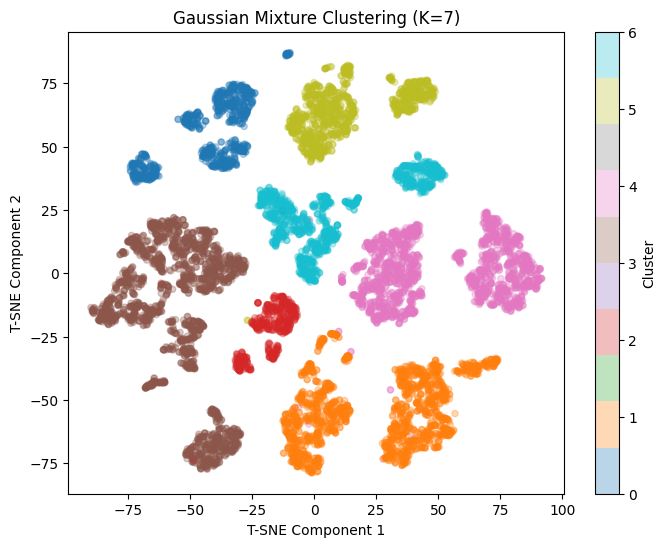

In [22]:

plt.figure(figsize=(8,6))
plt.scatter(
    X_Unscaled[:, 0],
    X_Unscaled[:, 1],
    c=labels,
    cmap='tab10',
    s=20,alpha=0.3
    
)

plt.xlabel("T-SNE Component 1")
plt.ylabel("T-SNE Component 2")
plt.title("Gaussian Mixture Clustering (K=7)")
plt.colorbar(label="Cluster")
plt.show()


In [23]:
bic = []
aic = []
silh = []

for i in range(2, 10):
    gm = GaussianMixture(n_components=i, random_state=42)
    gm.fit(pca_components)
    
    bic.append(gm.bic(pca_components))
    aic.append(gm.aic(pca_components))
    
    labels = gm.predict(pca_components)  
    silh.append(silhouette_score(pca_components, labels))

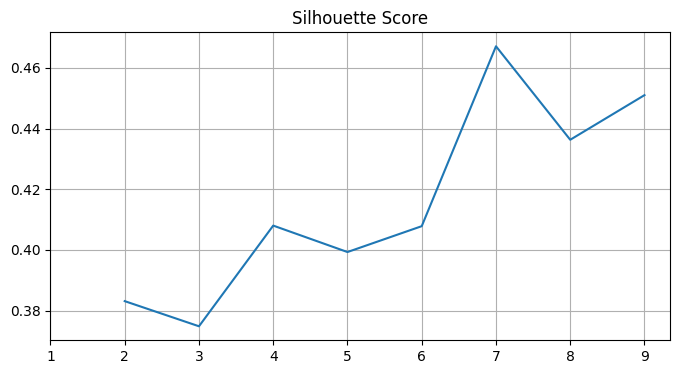

In [24]:
plt.figure(figsize = (8,4))
plt.plot(range(2,10), silh)
plt.title('Silhouette Score')
plt.xticks(range(1,10))
plt.grid()
plt.show()

In [50]:
df_stan['label']=labels_cnt

In [51]:
df_stan.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,label
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,3
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,6
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12,0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,6


In [53]:
df_stan.groupby('label').mean()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
label,,,,,,,,,,,,,,,,,
0,2339.547533,0.925388,659.668843,659.828856,0.000000,2029.071979,0.275819,0.275508,0.000000,0.292888,6.834577,6.288557,4634.607644,1917.229855,1028.009944,0.057742,11.353234
1,399.703452,0.788510,537.855765,0.000000,538.630039,0.000000,0.705865,0.000000,0.672206,0.000000,0.000000,11.809126,3109.690253,732.797761,716.294690,0.305723,11.507513
2,2564.240909,0.955563,533.374707,0.000000,534.022842,2050.556152,0.650528,0.000000,0.603486,0.262164,6.214751,12.238612,4351.626898,1950.880505,1444.167442,0.047648,11.318872
3,2150.187407,0.882479,0.000000,0.000000,0.000000,1991.030938,0.000000,0.000000,0.000000,0.272965,6.303580,0.000000,4028.737324,1655.461452,1005.345748,0.044269,11.317312
4,1211.432773,0.931958,2457.888949,1503.322192,954.835752,0.000000,0.810817,0.458925,0.645180,0.000000,0.000000,34.356616,5701.761396,2288.037343,612.449265,0.256607,11.804089
5,2834.030531,0.968592,1926.977076,1158.485584,768.878263,2084.891184,0.776399,0.395263,0.627469,0.291094,7.717370,30.387635,5803.347508,3006.808901,1246.851590,0.068997,11.617272
6,762.608963,0.769453,883.035435,883.035435,0.000000,0.000000,0.355049,0.355049,0.000000,0.000000,0.000000,7.733396,4429.757349,1202.369739,497.152149,0.136120,11.556595


cluster 0 no  installements but purchses many and cash advances 

cluster 1 installments only

cluster 2 cash advance and almost all purchses are  installments

cluster 3 cash advance only

cluster 4 purchases and installments but no cash advances 

cluster 5 all things of cash , puchases and installments 

cluster 6 puchases only 


In [38]:
df['label'].value_counts()

label
3    2039
1    1797
4    1761
6    1069
5    1019
0     804
2     461
Name: count, dtype: int64

In [54]:
df.shape

(8950, 17)